# Causal-Inference Pipeline for Humanities Data
**Evening Star, 17 June 1920 — *Did the League's inaction cause its loss of credibility?***

This notebook runs the same six-step pipeline as `run_pipeline.py`, narrated cell by cell. It is offline and rule-based (no API key).

In [1]:
import sys; sys.path.insert(0, '.')
from src import clean_newspapers, extract_ekg, build_graph, causal_model, inference

## Step 1–2 · Clean & segment
Strip page markers, repair OCR line breaks, segment into articles. Every transformation is logged.

In [2]:
arts = clean_newspapers.run()
print('articles:', len(arts))
arts[:3]

[clean] load: 28061 raw lines, 864515 chars from 1920-06-17.txt
[clean] strip_markers: removed 33 page/issue marker lines
[clean] drop_running_headers: removed 6 running-header lines
[clean] segment_articles: produced 585 article segments (>=200 chars)
[clean] write: 585 articles -> articles.jsonl
articles: 585


[Article(id='art:1920-06-17:000:backer-of-johnson', headline='Backer Of Johnson', text='SAYS HE\'S FOR TICKET\\ It. B. Strassburger, Prominent in Aiding Californian. Calls on p" Republican Nominee. Senator Harding formally announced today that his campaign as the re publican presidential candidate wouldnot be a one-man affair; that the aid and advice of every republican leader ?would be sought. He declared thatthis would be his policy, not only dur rng the campaign, but later, shouldhe be elected President. "1 will see every republican; all re publicans look alike to me," said he. Besides his own announcement on the subject, the senator authorized Robert Armstrong, his political rep resentative. to say that the "policy of the senator will be to receive and in T^e ihe opinion and advice of every ^/"republican regardless of what partof the party he belonds to. "The senator desires not to be a one-man candidate any more than he desires to be a one-man President, if elected." said Mr. Arms

## Step 3 · Extract entities, events, causal assertions
A transparent causal-cue lexicon; every assertion keeps its supporting quote.

In [3]:
nodes, edges, records = extract_ekg.extract()
print('causal assertions:', len(records))
[r for r in records if 'league' in (r['cause']+r['effect']+r['quote']).lower()]

nodes by type: {'Source': 1, 'Article': 585, 'Person': 4747, 'Organization': 212, 'Place': 100, 'Concept': 160, 'Mention': 83, 'CausalAssertion': 83}
edges: 7483 | causal assertions: 83
causal assertions: 83


[{'ca_id': 'ca:010:0006',
  'article_id': 'art:1920-06-17:010:in-persia-s-plea',
  'relationType': 'causes',
  'polarity': 'positive',
  'confidence': 0.6,
  'cause': 'Called "Pompon* Farce.** The Times captions its editorial on the subject "A Pompous Farce" and calls yesterday\'s proceed',
  'effect': 'discredit being brought upon the league." "This body (the council) was pledged to the furtherance of open diplomacy," co',
  'cue': '\\bthe cause of\\b',
  'quote': 'Called "Pompon* Farce.** The Times captions its editorial on the subject "A Pompous Farce" and calls yesterday\'s proceedings "humili ating." It savs: ""Malice was the cause of discredit being brought upon the league." "This body (the council) was pledged to the furtherance of open diplomacy," complains the Pally News, "but threw no light on the text of the correspondence which has passed be tween the Persian and soviet gov ernments and certain conditions al leged to have been imposed.'},
 {'ca_id': 'ca:010:0007',
  'articl

## Step 4 · Build the knowledge graph
networkx property graph → CSV + GraphML, provenance on every node.

In [4]:
G = build_graph.build()
build_graph.summarize(G)
build_graph.export(G)

nodes: 5971 edges: 6824
node types: {'Person': 4747, 'Article': 585, 'Organization': 212, 'Concept': 160, 'Place': 100, 'Mention': 83, 'CausalAssertion': 83, 'Source': 1}
edge rels : {'MENTIONS': 5824, 'DERIVED_FROM': 668, 'SUPPORTED_BY': 83, 'CAUSE': 83, 'EFFECT': 83, 'EVIDENCE': 83}


wrote ekg.graphml


## Step 5 · Build the causal model (DAG)
Asserted vs analyst-added edges; find the backdoor and the adjustment set.

In [5]:
dag = causal_model.build_dag()
Z, bdoor = causal_model.find_adjustment_set(dag, 'T', 'O')
print('backdoor paths:', [' - '.join(p) for p in bdoor])
print('adjustment set:', Z)
causal_model.render(dag)

backdoor paths: ['T - U - O']
adjustment set: {'U'}
wrote causal_dag.png


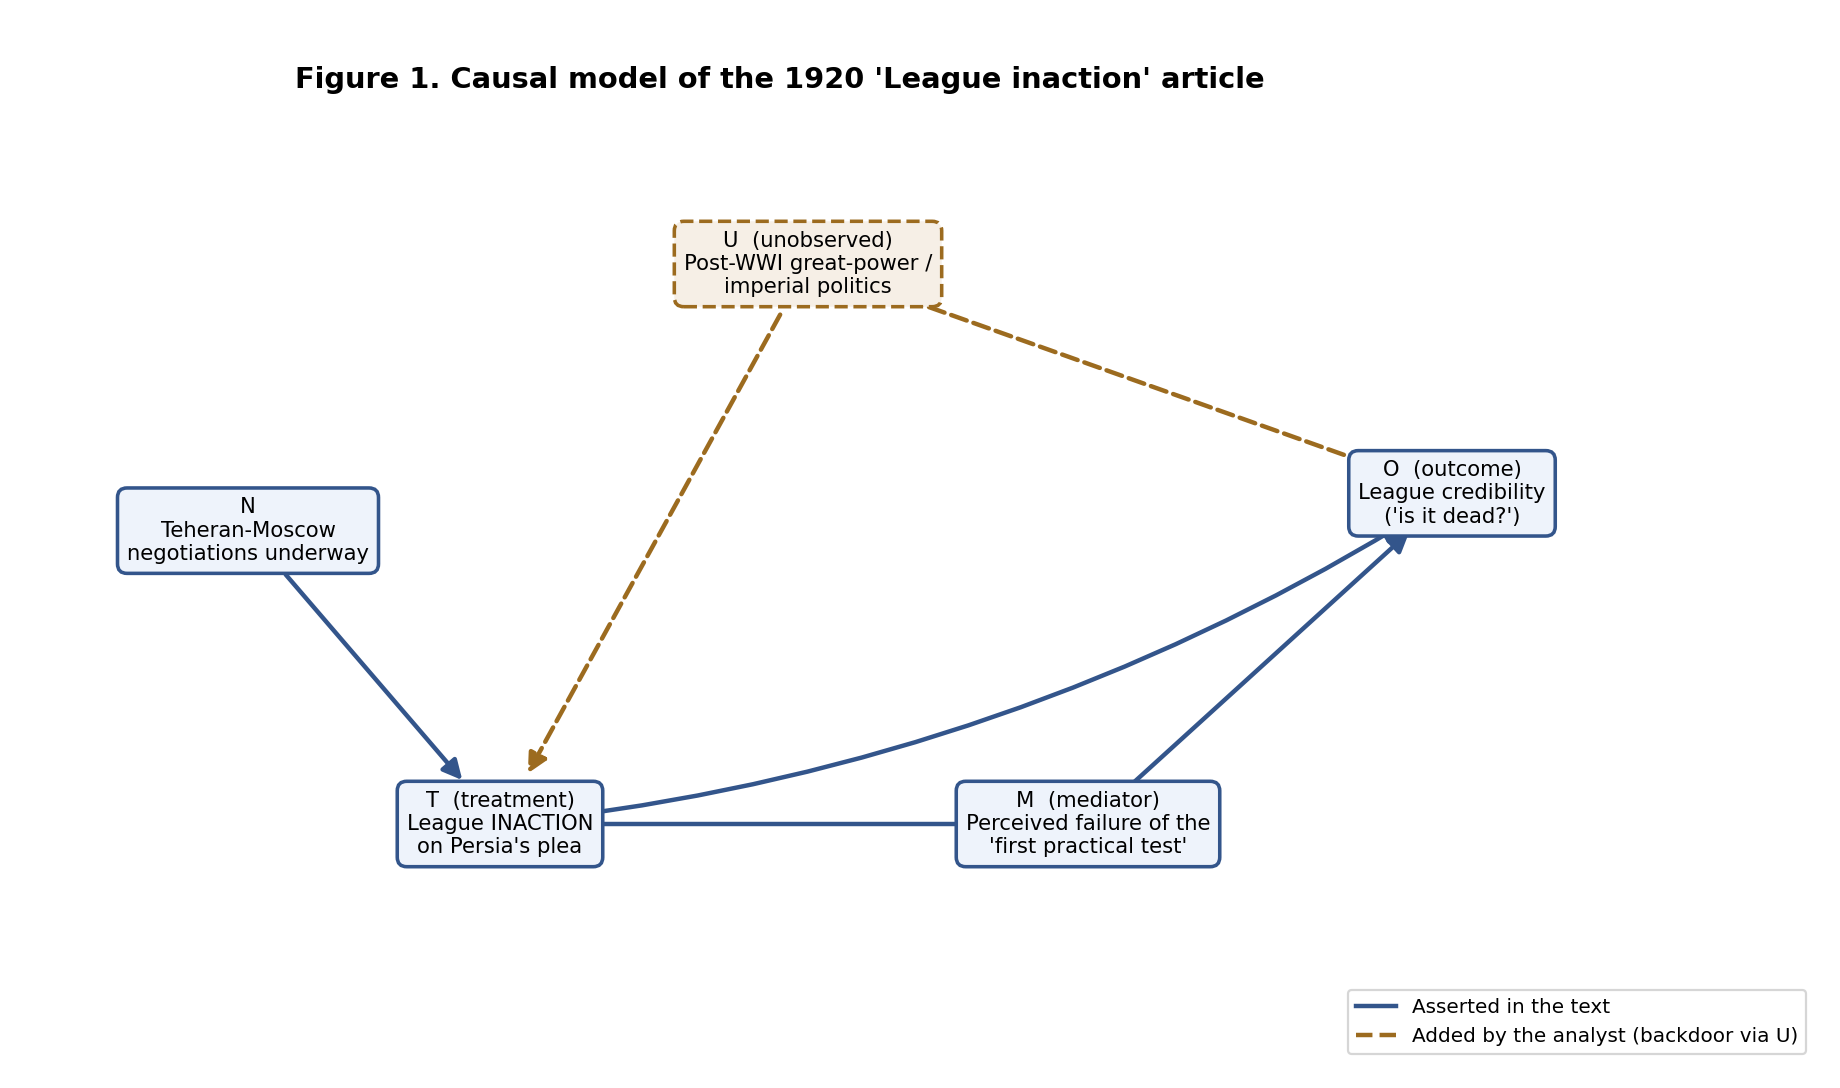

In [6]:
from IPython.display import Image
Image('figures/causal_dag.png')

## Step 6 · Causal inference
Motif leaderboard, contradictions, and the focused verdict — separating correlation, asserted causation, and identified effect.

In [7]:
inference.run()

loaded 83 causal assertions

Top causal motifs (cause -> effect, weighted by confidence):
  [1.10] henfh man boys  --causes-->  inn toet nvr
  [1.10] delay delivery woolens  --causes-->  these famous makers
  [1.10] late delivery your  --causes-->  join crowds buying
  [1.10] present tight money  --causes-->  boston has been
  [1.10] bubonic plague quarantine  --causes-->  june sus pension
  [1.00] proposed oceanic exploration  --causes-->  saving shipping through
  [0.60] called pompon farce  --causes-->  discredit being brought
  [0.60] gompers ruling  --causes-->  tha molders delegation
  [0.60] meadsof grange tfie  --causes-->  killing henry
  [0.60] bad tooth may  --causes-->  ray will show

Contradiction pairs (opposite polarity, same cause/effect): 0
Evidence density computed for 83 assertions (max 79 words, min 7 words).

================ FOCUSED INFERENCE: the League question =====================
Question : Did the League's INACTION on Persia (T) CAUSE the loss of its
       

**Conclusion.** The asserted effect `T → O` is *not identified*: the only backdoor `T ← U → O` runs through an unobserved confounder (post-WWI great-power politics) the article never measures. A confident rung-two 'because' on zero rung-one evidence — the same gap the worked eugenics example exposes.